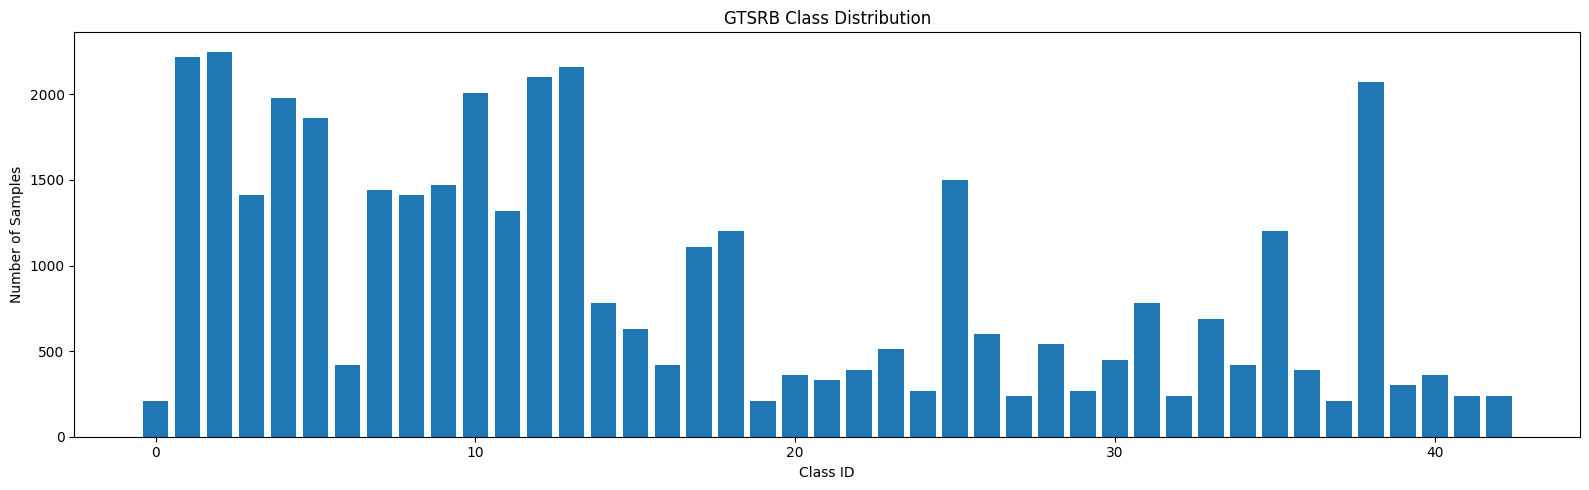

Total training samples: 39209
Most frequent class: 2 (2250 samples)
Least frequent class: 0 (210 samples)
Imbalance ratio: 10.7x


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

TRAIN_DIR = "../data/Train"

class_counts = {}
for class_id in sorted(os.listdir(TRAIN_DIR)):
    class_path = os.path.join(TRAIN_DIR, class_id)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        class_counts[int(class_id)] = count

plt.figure(figsize=(16, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class ID")
plt.ylabel("Number of Samples")
plt.title("GTSRB Class Distribution")
plt.tight_layout()
plt.show()

print(f"Total training samples: {sum(class_counts.values())}")
print(f"Most frequent class: {max(class_counts, key=class_counts.get)} ({max(class_counts.values())} samples)")
print(f"Least frequent class: {min(class_counts, key=class_counts.get)} ({min(class_counts.values())} samples)")
print(f"Imbalance ratio: {max(class_counts.values()) / min(class_counts.values()):.1f}x")

In [ ]:
fig, axes = plt.subplots(6, 8, figsize=(16, 12))
axes = axes.flatten()

for class_id in range(43):
    class_path = os.path.join(TRAIN_DIR, str(class_id))
    sample_img_path = os.path.join(class_path, os.listdir(class_path)[0])
    img = cv2.imread(sample_img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[class_id].imshow(img)
    axes[class_id].set_title(f"Class {class_id}", fontsize=7)
    axes[class_id].axis("off")

# hide unused subplots
for i in range(43, len(axes)):
    axes[i].axis("off")

plt.suptitle("One Sample Per Class", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
sizes = []
for class_id in range(43):
    class_path = os.path.join(TRAIN_DIR, str(class_id))
    for img_name in os.listdir(class_path)[:10]:  # sample 10 per class
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            sizes.append(img.shape[:2])

heights, widths = zip(*sizes)
print(f"Height range: {min(heights)}px to {max(heights)}px")
print(f"Width range: {min(widths)}px to {max(widths)}px")
print(f"Most common size: {max(set(sizes), key=sizes.count)}")

In [4]:
import sys
sys.path.append("../src")
from preprocessing import load_and_preprocess, load_dataset
import matplotlib.pyplot as plt

# test single image first
test_img_path = "../data/Train/0/" + os.listdir("../data/Train/0")[0]
img = load_and_preprocess(test_img_path, img_size=32, use_clahe=False)

print(f"Shape: {img.shape}")      # should be (32, 32, 3)
print(f"Min: {img.min():.3f}")    # should be >= 0.0
print(f"Max: {img.max():.3f}")    # should be <= 1.0
print(f"Dtype: {img.dtype}")      # should be float32

Shape: (32, 32, 3)
Min: 0.208
Max: 1.000
Dtype: float32


In [ ]:
X_train, y_train = load_dataset("../data/Train", img_size=32, use_clahe=False)

print(f"X_train shape: {X_train.shape}")   # should be (39209, 32, 32, 3)
print(f"y_train shape: {y_train.shape}")   # should be (39209,)
print(f"Memory usage: {X_train.nbytes / 1e6:.1f} MB")

In [ ]:
print(os.listdir("../data/Test"))

In [5]:
import pandas as pd
test_csv = pd.read_csv("../data/Test.csv")
print(test_csv.head())
print(f"\nColumns: {test_csv.columns.tolist()}")
print(f"Total test samples: {len(test_csv)}")

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6      43      47       38  Test/00002.png
3     27      29       5       5      22      24       33  Test/00003.png
4     60      57       5       5      55      52       11  Test/00004.png

Columns: ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']
Total test samples: 12630


In [6]:
from preprocessing import load_test_dataset

X_test, y_test = load_test_dataset("../data/Test.csv", "../data", img_size=32)
print(f"X_test shape: {X_test.shape}")    # should be (12630, 32, 32, 3)
print(f"y_test shape: {y_test.shape}")    # should be (12630,)

X_test shape: (12630, 32, 32, 3)
y_test shape: (12630,)
